In [1]:
from __future__ import annotations

import runpy
from pathlib import Path
%config InlineBackend.figure_format = 'retina'

_NOTEBOOK_SETUP = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    helper = candidate / "figures_code" / "notebook_setup.py"
    if helper.exists():
        _NOTEBOOK_SETUP = runpy.run_path(str(helper))
        break
if _NOTEBOOK_SETUP is None:
    raise RuntimeError("Could not locate figures_code/notebook_setup.py")

REPO_ROOT = _NOTEBOOK_SETUP["REPO_ROOT"]

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from CANN_DDM_model_rate_based import CANN_DDM_model
from rate_model_core.default_params import build_stable_default_params



In [ ]:
MAR = 0.01
SEED = 7
DT_DDM = 5.0
DT_MODEL = 1.0
T_START = 10.0
DUR = 2000
THETA_MARGIN = 0.02
#C_BE_SWEEP = np.array([0.0, 0.04], dtype=float)
C_BE_SWEEP = np.array([0.0, 0.01], dtype=float)
MIN_ACCUMULATION_SAMPLES = 40
np.random.seed(SEED)


MODEL_STRIDE = int(round(float(DT_MODEL)))
if MODEL_STRIDE <= 0 or not np.isclose(float(DT_MODEL), float(MODEL_STRIDE)):
    raise ValueError("DT_MODEL must be a positive integer number of milliseconds for this notebook.")
T_START_IDX = int(round(float(T_START) / float(DT_MODEL)))
if not np.isclose(float(T_START), float(T_START_IDX) * float(DT_MODEL)):
    raise ValueError("T_START must align to the DT_MODEL sampling grid in this notebook.")


def build_baseline_params(*, c: float, v: float, x0: float = 0.5, seed: int = SEED, kappa: float | None = None) -> dict:
    params = build_stable_default_params()
    params["bump_pop"]["noise_scale_bump"] = 0.0
    params["bump_pop"]["sigma_B"] = 0.08
    # params["bump_pop"]["tau_B"] = 0.15
    # params["edge_pop"]["noise_scale_edge"] = 0.0
    params["edge_pop"]["c_EB"] = 0.2
    params["edge_pop"]["tau_E"] = 0.3



    c_be_params = {
        "mode": "target_diffusion",
        "theta_margin": THETA_MARGIN,
    }
    if kappa is not None:
        c_be_params["kappa"] = float(kappa)
    params["bump_pop"]["c_BE_params"] = c_be_params

    params["decision_space_params"]["decision_mode"] = "continuous"
    params["decision_space_params"]["t_start"] = T_START
    params["decision_space_params"]["mar"] = MAR
    params["decision_space_params"]["dur"] = DUR
    params["decision_space_params"]["dt_DDM"] = DT_DDM
    params["decision_space_params"]["x0"] = float(x0)
    params["decision_space_params"]["seed"] = int(seed)
    params["decision_space_params"]["drift_rate"] = float(v)
    params["decision_space_params"]["noise_scale"] = float(c)
    return params


def prepare_shared_calibration(seed: int = SEED):
    model = CANN_DDM_model(CANN_params=build_baseline_params(c=0.0, v=0.0, seed=seed))
    calibration = model.prepare_target_diffusion_mode(
        c_be_sweep=C_BE_SWEEP,
        min_accumulation_samples=MIN_ACCUMULATION_SAMPLES,
    )
    return calibration


def run_cases(*, cases: dict, kappa: float):
    results = {}
    for key in cases.keys():
        case = cases[key]
        model = CANN_DDM_model(
        CANN_params=build_baseline_params(
            c=case["c"],
            v=case["v"],
            seed=case["seed"],
            kappa=kappa,
        ))
        runner = model.run_simulation(
            mon_vars=["r_E", "r_B", "x_E", "x_B", "theta_E", "theta_B", "v_drift", "v_noise", "v_drive", "hit_boundary"],
            progress_bar=False,
            dt=DT_MODEL,
        )
        RT = runner.rt_ms
        x_ref_full = np.asarray(model.x_traj[:int(model.t_start+RT)], dtype=float)
        x_ref = x_ref_full[::MODEL_STRIDE]
        results[key] = {
            "label": case["label"],
            "seed": int(case["seed"]),
            "v": float(case["v"]),
            "c": float(case["c"]),
            "times": np.arange(len(x_ref), dtype=float) * DT_MODEL,
            "x_ref": x_ref,
            "x_E": np.asarray(runner.mon.x_E[:int(model.t_start+RT)]).reshape(-1),
            "x_B": np.asarray(runner.mon.x_B[:int(model.t_start+RT)]).reshape(-1),
            "theta_E": np.asarray(runner.mon.theta_E[:int(model.t_start+RT)]).reshape(-1),
            "theta_B": np.asarray(runner.mon.theta_B[:int(model.t_start+RT)]).reshape(-1),
            "v_drift": np.asarray(runner.mon.v_drift[:int(model.t_start+RT)]).reshape(-1),
            "v_noise": np.asarray(runner.mon.v_noise[:int(model.t_start+RT)]).reshape(-1),
            "v_drive": np.asarray(runner.mon.v_drive[:int(model.t_start+RT)]).reshape(-1),
            "hit_boundary": bool(np.any(np.asarray(runner.mon.hit_boundary).reshape(-1))),
        }
    return results

def summarize_case(result: dict, calibration: dict) -> dict:
    return {
        "label": result["label"],
        "v": float(result["v"]),
        "c": float(result["c"]),
        "mean_abs_error_xE": float(np.mean(np.abs(result["x_E"][T_START_IDX:] - result["x_ref"][T_START_IDX:]))),
        "mean_abs_error_xB": float(np.mean(np.abs(result["x_B"][T_START_IDX:] - result["x_ref"][T_START_IDX:]))),
        "alignment_mean_abs": float(np.mean(np.abs(result["theta_B"][T_START_IDX:] - result["theta_E"][T_START_IDX:]))),
        "c_be_theta_max": float(calibration["c_be_theta_max"]),
        "certificate_passed": bool(calibration["certificate_passed"]),
        "hit_boundary": bool(result["hit_boundary"]),
    }



def plot_cases_traj(result: dict):
    fig, axes = plt.subplots(1, 1, figsize=(6, 4), sharex=True)
    colors = ["#D73027", "#1A9850"]
    for enum, case in enumerate(result.keys()):
        axes.plot(result[case]["times"], result[case]["x_ref"], color=colors[enum], label=f"Coh={result[case]['v']/3} (DDM)", alpha=.5, linewidth=1.5)
        axes.plot(result[case]["times"], result[case]["x_E"], color=colors[enum], linestyle="--", label=f"Coh={result[case]['v']/3} (circuit)", alpha=0.8,
                  linewidth=1.5)
        axes.plot(result[case]["times"], result[case]["x_B"], color=colors[enum], linestyle=":", label=f"Coh={result[case]['v']/3} (circuit)", linewidth=1.0)

        axes.axvline(T_START, color="#9ca3af", linestyle=":")
        axes.axhline(1, color="black", linestyle="--")
        axes.axhline(0, color="black", linestyle="--")


def plot_cases_traj_and_v_drive(result: dict):
    fig, axes = plt.subplots(2, 1, figsize=(5, 6.2), sharex=True)
    colors = ["#D73027", "#1A9850"]
    for enum, case in enumerate(result.keys()):
        # Trajectory subplot (top)
        axes[0].plot(result[case]["times"], result[case]["x_ref"], color=colors[enum], label=f"Coh={result[case]['v']/3} (DDM)", alpha=0.5, linewidth=1.0)
        axes[0].plot(result[case]["times"], result[case]["x_E"], color=colors[enum], linestyle="--", label=f"Coh={result[case]['v']/3} (circuit)", linewidth=1.0)
        axes[0].plot(result[case]["times"], result[case]["x_B"], color=colors[enum], linestyle=":", label=f"Coh={result[case]['v']/3} (circuit)", linewidth=1.0)

        axes[0].axvline(T_START, color="#9ca3af", linestyle=":")
        axes[0].axhline(1, color="black", linestyle="--")
        axes[0].axhline(0, color="black", linestyle="--")
        axes[0].legend(frameon=False)
        axes[0].set_yticks([0, 0.5, 1])
        # Drive subplot (bottom)
        axes[1].plot(result[case]["times"], result[case]["v_drive"], color=colors[enum], linestyle="-", label=f"Coh={result[case]['v']/3}", linewidth=1.0)
        axes[1].axvline(T_START, color="#9ca3af", linestyle=":", linewidth=1.0)
        axes[1].legend(frameon=False)
    for label in axes[0].get_xticklabels():
        label.set_fontsize(14)
    for label in axes[0].get_yticklabels():
        label.set_fontsize(14)
    for label in axes[1].get_xticklabels():
        label.set_fontsize(14)
    for label in axes[1].get_yticklabels():
        label.set_fontsize(14)
    plt.tight_layout()
    return fig, axes
  


In [39]:
calibration = prepare_shared_calibration()
shared_calibration_summary = {
    "kappa": float(calibration["kappa"]),
    "c_be_theta_max": float(calibration["c_be_theta_max"]),
    "certificate_passed": bool(calibration["certificate_passed"]),
}
shared_calibration_summary

{'kappa': 0.06280558552052251,
 'c_be_theta_max': 0.13033496299833744,
 'certificate_passed': True}

0.01


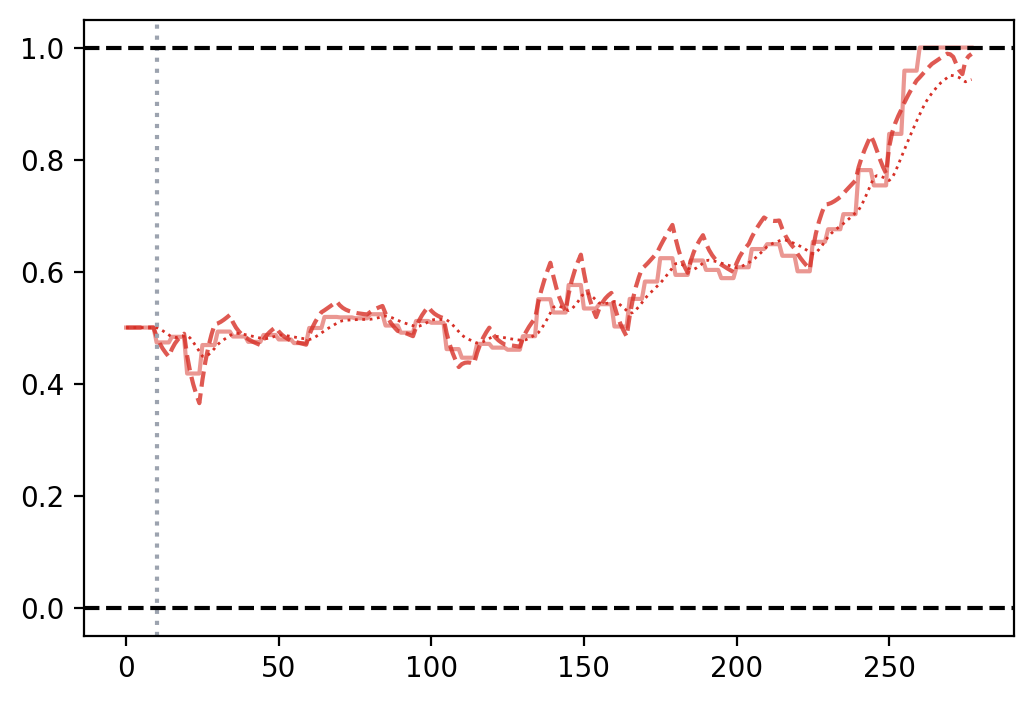

In [40]:

case1 = {
    "label": "case2",
    "seed": 2026,
    "v": .3,
    "c": .5,
}
cases = {
    "case1": case1
}
results = run_cases(cases=cases, kappa=float(calibration["kappa"]))
plot_cases_traj(results)

In [23]:
params

NameError: name 'params' is not defined